In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import ast

In [2]:
import pandas as pd

# Define file paths for ads and articles datasets
ads_dataset_paths = [
    "../datasets/ads_dataset_24-05-2024.csv",
    "../datasets/ads_dataset_30-05-2024.csv",
    "../datasets/ads_dataset_04-06-2024.csv",
    "../datasets/ads_dataset_07-06-2024.csv",
]

articles_dataset_paths = [
    "../datasets/articles_dataset_24-05-2024.csv",
    "../datasets/articles_dataset_30-05-2024.csv",
    "../datasets/articles_dataset_04-06-2024.csv",
    "../datasets/articles_dataset_07-06-2024.csv",
]

# Combine all file paths into a single list for easier processing
all_dataset_paths = ads_dataset_paths + articles_dataset_paths

# Read all datasets into DataFrames and store them in a dictionary
dataframes = {}
for i, file_path in enumerate(all_dataset_paths, start=1):
    # Read CSV file into a DataFrame
    dataframes[f'df_{i}'] = pd.read_csv(file_path)

In [3]:
# Concatenate ads DataFrames into a single DataFrame
ads_df = pd.concat([dataframes[f'df_{i}'] for i in range(1, 5)], ignore_index=True)

# Concatenate articles DataFrames into a single DataFrame
article_df = pd.concat([dataframes[f'df_{i}'] for i in range(5, 9)], ignore_index=True)


In [10]:
# Convert string representation of lists in 'Image_Links' to actual lists
article_df['Image_Links'] = article_df['Image_Links'].apply(ast.literal_eval)

# Calculate the number of images per article and create a new column
article_df['Num_of_screen'] = article_df['Image_Links'].apply(len)

# Calculate the total number of screenshots across all articles
screenshot_num = article_df['Num_of_screen'].sum()


In [4]:
# Data Quality Assessment

# Check for missing values in the ads DataFrame
missing_values = ads_df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

# Get a summary of total missing values in the DataFrame
total_missing_values = ads_df.isnull().sum().sum()
print(f"Total number of missing values: {total_missing_values}")

# Check for duplicate entries in the ads DataFrame
duplicates = ads_df.duplicated()

# Get the number of duplicate rows
num_duplicates = duplicates.sum()
print(f"Number of duplicate rows: {num_duplicates}")

Missing values in each column:
Folder_Number       0
Image_Link          0
Ad_Name            77
Product           123
Company           189
Ad_Description     25
Ad_Placement        3
dtype: int64
Total number of missing values: 417
Number of duplicate rows: 27


In [5]:
# Display duplicate rows in the ads DataFrame
duplicate_rows = ads_df[duplicates]
print("Duplicate rows:")
print(duplicate_rows)

Duplicate rows:
     Folder_Number                                         Image_Link  \
92             535  https://drive.google.com/file/d/1EBD7DAowjG5wf...   
122            529  https://drive.google.com/file/d/1C_9cHTOZveOHH...   
477            S21  https://drive.google.com/file/d/1YrMJmg8jxkpAF...   
536            S23  https://drive.google.com/file/d/1NqHlfNk-c0s7V...   
566            557  https://drive.google.com/file/d/14-yJQalgrN-Pj...   
567            557  https://drive.google.com/file/d/14-yJQalgrN-Pj...   
618            548  https://drive.google.com/file/d/1XoQKPl_S_Pdjq...   
623            548  https://drive.google.com/file/d/1LjSGM9kBR-7WJ...   
651            547  https://drive.google.com/file/d/1fErObjuEihP2B...   
663            547  https://drive.google.com/file/d/1_jcmK-_RBRMES...   
675            589  https://drive.google.com/file/d/1pYbEQzfqSYJ6X...   
714            473  https://drive.google.com/file/d/1xbisowX5vCq6N...   
720            473  https://drive.g

In [6]:
# Remove duplicate rows from the ads DataFrame and reset the index
ads_df = ads_df.drop_duplicates().reset_index(drop=True)

# Remove rows where 'Ad Name', 'Product', and 'Company' are all null
ads_df = ads_df[~ads_df[['Ad_Name', 'Product', 'Company']].isnull().all(axis=1)]

print(ads_df.isnull().sum())

Folder_Number       0
Image_Link          0
Ad_Name            33
Product            72
Company           143
Ad_Description      9
Ad_Placement        0
dtype: int64


In [7]:
# Define a list of unwanted ad names and companies to filter out
unwanted_ad_names = [
    'Google Ads',
    'Ads by Google',
    'Advertisement from Google',
    'Ad using Google',
    'Google Ads Placeholder',
    'Google Ad',
    'Anuncio servido por Google'
]

# Remove rows with unwanted ad names
ads_df = ads_df[~ads_df['Ad_Name'].isin(unwanted_ad_names)]

# Remove rows where the company is 'Google'
ads_df = ads_df[ads_df['Company'] != 'Google']

In [8]:
# Basic Statistics

# Total number of ads
total_ads = len(ads_df)

# Count unique products, excluding NA entries
unique_products = ads_df['Product'].dropna().nunique()

# Count unique companies, excluding NA entries
unique_companies = ads_df['Company'].dropna().nunique()

# Distribution of ad placements
ad_placement_distribution = ads_df['Ad_Placement'].value_counts()

# Calculate ad name length statistics
ad_name_length = ads_df['Ad_Name'].str.len()
average_ad_name_length = ad_name_length.mean()
median_ad_name_length = ad_name_length.median()
max_ad_name_length = ad_name_length.max()

# Calculate ad description length statistics
ad_description_length = ads_df['Ad_Description'].str.len()
average_description_length = ad_description_length.mean()
median_description_length = ad_description_length.median()
max_description_length = ad_description_length.max()

# Get the top 20 products by count
product_distribution = ads_df['Product'].dropna().value_counts().head(20)

# Get the top 20 companies, excluding 'Unknown' and 'Not specified'
company_representation = ads_df['Company'].dropna().value_counts()
company_representation = company_representation[~company_representation.index.isin(['Unknown', 'Not specified'])]
company_representation = company_representation.head(20)


In [11]:
# Summary of the statistics

# Create a dictionary to store the statistics
statistics = {
    'Total Number of ScreenShots': screenshot_num,  # Assuming screenshot_num is defined elsewhere
    'Total Number of Ads': total_ads,
    'Unique Products': unique_products,
    'Unique Companies': unique_companies,
    'Average Ad Name Length': average_ad_name_length,
    'Median Ad Name Length': median_ad_name_length,
    'Max Ad Name Length': max_ad_name_length,
    'Average Ad Description Length': average_description_length,
    'Median Ad Description Length': median_description_length,
    'Max Ad Description Length': max_description_length,
}

# Print the summary of statistics
for key, value in statistics.items():
    print(f"{key}: {value}")


Total Number of ScreenShots: 1023
Total Number of Ads: 1483
Unique Products: 983
Unique Companies: 512
Average Ad Name Length: 18.12233676975945
Median Ad Name Length: 16.0
Max Ad Name Length: 107.0
Average Ad Description Length: 63.13918918918919
Median Ad Description Length: 60.0
Max Ad Description Length: 249.0


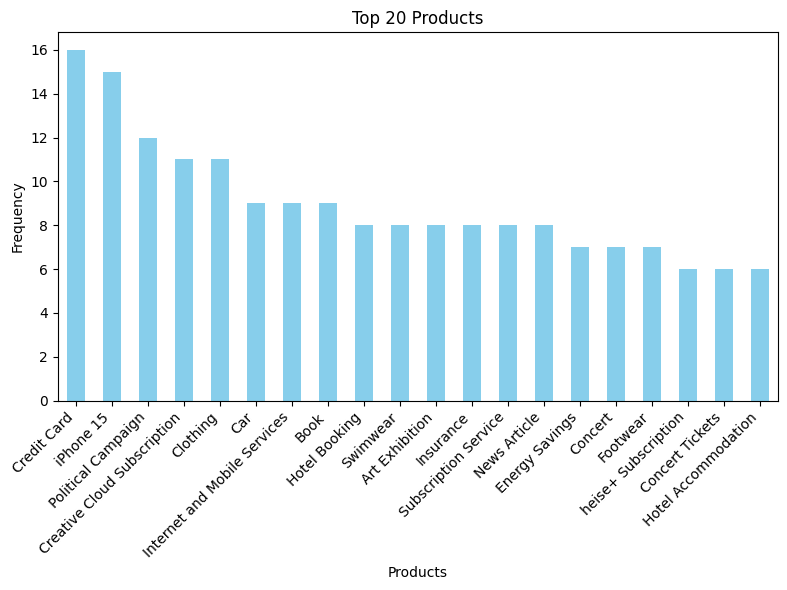

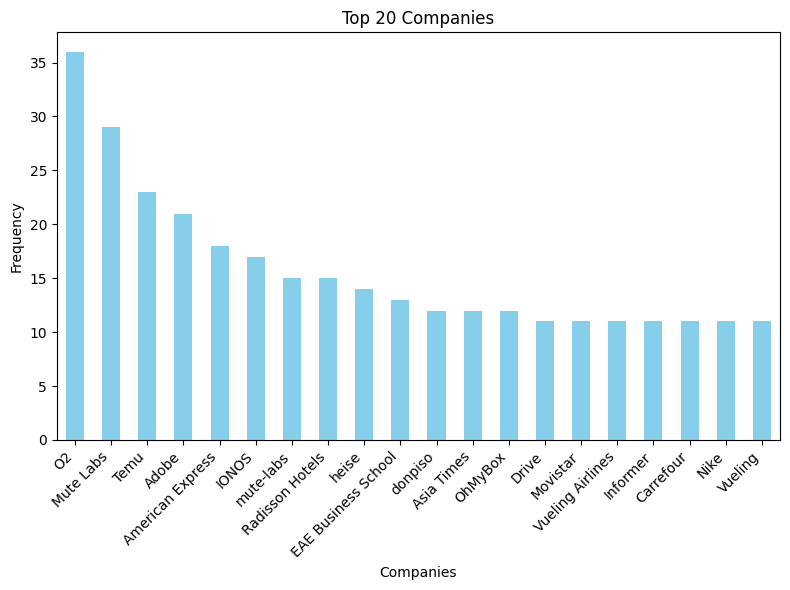

In [12]:
# Plot the product distribution
plt.figure(figsize=(8, 6))
product_distribution.plot(kind='bar', color='skyblue')

# Add labels and title for the product distribution plot
plt.xlabel('Products')
plt.ylabel('Frequency')
plt.title('Top 20 Products')
plt.xticks(rotation=45, ha='right')  # Rotate the x labels for better readability
plt.tight_layout()  # Adjust layout to prevent label cut-off

# Show the product distribution plot
plt.show()

# Plot the company representation
plt.figure(figsize=(8, 6))
company_representation.plot(kind='bar', color='skyblue')

# Add labels and title for the company representation plot
plt.xlabel('Companies')
plt.ylabel('Frequency')
plt.title('Top 20 Companies')
plt.xticks(rotation=45, ha='right')  # Rotate the x labels for better readability
plt.tight_layout()  # Adjust layout to prevent label cut-off

# Show the company representation plot
plt.show()
